# Assignment 4 — Data Visualization and Data Storytelling
## What Separates a Q3 Driver? A Data Story from the 2026 Australian GP

**Disciplina:** Data Science (Optativa I)  
**FURB — Universidade Regional de Blumenau**  
**Aluno:** Felipe Tomelin  

---

> *"Data storytelling is not just a collection of visualizations. It is a form of writing: a structured narrative that uses evidence to make an argument."*  
> — Berinato, 2016 (via Lecture 14)

---

### Lecture reference: where this fits in the pipeline

In previous assignments we answered two different types of questions about the 2026 Australian GP qualifying data:

| Assignment | Stage | Question | Output |
|---|---|---|---|
| 2 | Exploratory Data Analysis | *What patterns exist in the data?* | Distributions, correlations, statistical tests |
| 3 | Machine Learning | *Can we classify and cluster drivers automatically?* | K-Means clusters, Random Forest classifier |
| **4** | **Data Visualization & Storytelling** | **How can we make these findings understandable and meaningful to an audience?** | **Visual narrative, explanatory charts** |

This assignment operates in the **explanatory** quadrant: the goal is not to discover (we already did that), but to **communicate**.

## Section 1 — Framing the Story

Before designing any visual, the lecture principle is clear: *write the story first*.

### Context: how F1 qualifying works

In Formula 1, qualifying for a Grand Prix is divided into three knock-out sessions:

- **Q1** (all 20 drivers): the 5 slowest are eliminated
- **Q2** (15 remaining): the 5 slowest are eliminated  
- **Q3** (10 remaining): the fastest 10 drivers, who set the front two rows of the grid

Making it into **Q3 is the primary qualifying objective** for any competitive team. The difference between reaching Q3 and being eliminated in Q2 can define the entire race weekend — and often comes down to tenths of a second.

### The guiding question

> *In the 2026 Australian GP qualifying, what telemetry signals separate the drivers who made Q3 from those who didn't?*

Three previous analyses (Assignment 2: Kruskal-Wallis test with ε² = 0.83; Assignment 3: K-Means clustering and Random Forest with 100% LOOCV accuracy) all pointed to the same variable: **average lap speed**.

This notebook tells that story — visually and with narrative context.

In [1]:
# ── Imports and setup ─────────────────────────────────────────────────────
import json
import os
import warnings
import numpy as np
import pandas as pd
from scipy.stats import kruskal
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import (
    accuracy_score, silhouette_score,
    adjusted_rand_score, normalized_mutual_info_score
)
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio

warnings.filterwarnings("ignore")
pio.renderers.default = "png"
os.makedirs("iframe_figures", exist_ok=True)

# ── Design system — consistent with Assignments 2 and 3 ──────────────────
GROUP_COLORS  = {"Q3": "#00D4AA", "Q2": "#FFC906", "Q1": "#E8002D"}
VER_COLOR     = "#888888"
ACCENT_COLOR  = "#1F3864"

FEATURE_LABELS = {
    "speed_mean":    "Avg Speed",
    "speed_min":     "Min Speed",
    "speed_std":     "Speed Variability",
    "throttle_pct": "Throttle > 50%",
    "brake_pct":    "Braking",
}
FEATURES = list(FEATURE_LABELS.keys())

print("Setup complete.")

Setup complete.


In [2]:
# ── Data loading — same pipeline as Assignments 2 & 3 ────────────────────
DATA_PATH = "/Users/ftomelin/Documents/Repos/DataScienceFurb/data/raw/All Laps Update 13032026.csv"

df_all = pd.read_csv(DATA_PATH)
df_q = df_all[
    (df_all["session_type"] == "Q") &
    (df_all["event_name"]   == "Australian Grand Prix")
].copy().reset_index(drop=True)

best_q = (
    df_q.sort_values("lap_duration")
        .groupby("driver", sort=False)
        .first()
        .reset_index()
        .sort_values("lap_duration")
        .reset_index(drop=True)
)
best_q["rank"]  = range(1, len(best_q) + 1)
best_q["group"] = best_q["rank"].apply(
    lambda r: "Q3" if r <= 10 else ("Q2" if r <= 15 else "Q1")
)

def extract_features(row):
    raw = row.get("telemetry")
    if pd.isna(raw):
        return None
    try:
        frames = json.loads(raw)
    except Exception:
        return None
    if not frames:
        return None
    spd = [f["speed"]    for f in frames if f.get("speed")    is not None]
    thr = [f["throttle"] for f in frames if f.get("throttle") is not None]
    brk = [f["brake"]    for f in frames if f.get("brake")    is not None]
    if not spd:
        return None
    spd_arr = np.array(spd)
    return {
        "speed_mean":    float(spd_arr.mean()),
        "speed_min":     float(spd_arr.min()),
        "speed_std":     float(spd_arr.std()),
        "throttle_pct":  float(np.mean([1 if t > 50 else 0 for t in thr]) * 100) if thr else None,
        "brake_pct":     float(np.mean([1 if b > 0  else 0 for b in brk]) * 100) if brk else None,
    }

rows = []
for _, row in best_q.iterrows():
    feats = extract_features(row)
    if feats is None:
        continue
    rows.append({"driver": row["driver"], "group": row["group"],
                 "rank": row["rank"], "lap_duration": row["lap_duration"], **feats})

tdf = pd.DataFrame(rows)

# Competitive drivers (VER excluded — aborted out-lap)
tdf_c = tdf[tdf["driver"] != "VER"].copy().reset_index(drop=True)
ver   = tdf[tdf["driver"] == "VER"].iloc[0]

# Q3 threshold: midpoint between slowest Q3 and fastest Q2
THRESHOLD = (
    tdf_c[tdf_c["group"] == "Q3"]["speed_mean"].min() +
    tdf_c[tdf_c["group"] == "Q2"]["speed_mean"].max()
) / 2

print(f"Drivers with telemetry: {len(tdf)} total | {len(tdf_c)} competitive (VER excluded)")
print(f"Groups: {tdf_c['group'].value_counts().to_dict()}")
print(f"Q3 speed threshold: {THRESHOLD:.2f} km/h")

Drivers with telemetry: 20 total | 19 competitive (VER excluded)
Groups: {'Q3': 10, 'Q2': 5, 'Q1': 4}
Q3 speed threshold: 235.07 km/h


---
## Section 2 — The Answer at a Glance

The best data storytelling puts the conclusion first, then builds the evidence beneath it.  
This is sometimes called the **"inverted pyramid"** structure — a principle borrowed from journalism.

The chart below shows the answer directly: **average lap speed, from slowest to fastest, colored by qualifying group**.  
The dashed line marks the threshold that — in this race — separated drivers who made Q3 from those who didn't.

> *Preattentive attributes applied (Lecture 14, Slide 24): color encodes qualifying group, position encodes speed rank, and the threshold annotation directs attention to the key boundary.*

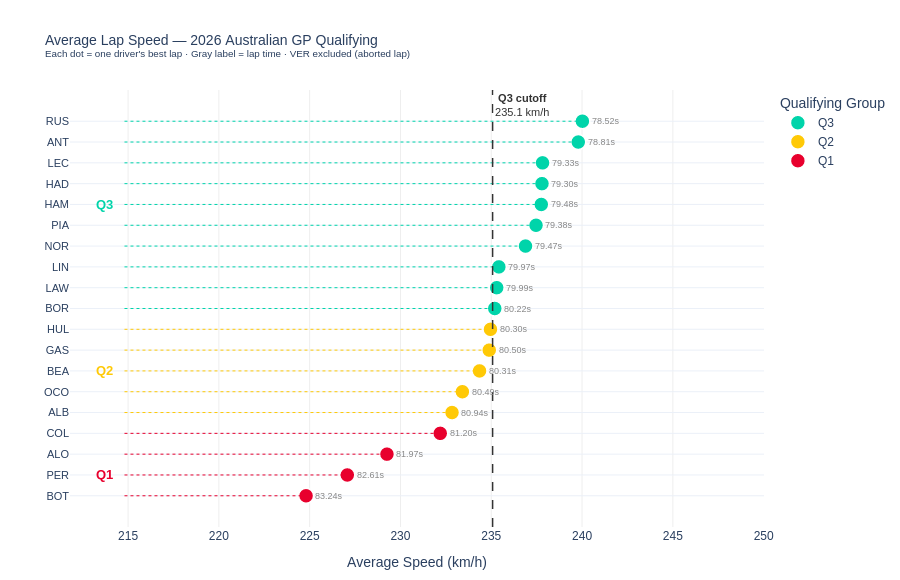

In [3]:
# ── Chart 1: Driver Speed Ranking — The Answer at a Glance ───────────────
df_ranked = tdf_c.sort_values("speed_mean", ascending=True).reset_index(drop=True)

fig = go.Figure()

# Lollipop stems
x_min = df_ranked["speed_mean"].min() - 10
for _, row in df_ranked.iterrows():
    fig.add_shape(
        type="line",
        x0=x_min, x1=row["speed_mean"],
        y0=row["driver"], y1=row["driver"],
        line=dict(color=GROUP_COLORS[row["group"]], width=1, dash="dot")
    )

# Dots by group
for grp in ["Q1", "Q2", "Q3"]:
    sub = df_ranked[df_ranked["group"] == grp]
    fig.add_trace(go.Scatter(
        x=sub["speed_mean"], y=sub["driver"],
        mode="markers",
        marker=dict(size=15, color=GROUP_COLORS[grp],
                    line=dict(width=1.5, color="white")),
        name=grp,
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Avg Speed: %{x:.1f} km/h<br>"
            f"Group: {grp}<extra></extra>"
        )
    ))

# Lap duration labels (secondary info)
for _, row in df_ranked.iterrows():
    fig.add_annotation(
        x=row["speed_mean"] + 0.4,
        y=row["driver"],
        text=f"{row['lap_duration']:.2f}s",
        showarrow=False,
        font=dict(size=9, color="#888"),
        xanchor="left"
    )

# Q3 threshold line
fig.add_vline(
    x=THRESHOLD,
    line_dash="dash", line_color="#333", line_width=1.5,
    annotation_text=f"<b>Q3 cutoff</b><br>{THRESHOLD:.1f} km/h",
    annotation_position="top right",
    annotation_font_size=11,
    annotation_font_color="#333",
    annotation_bgcolor="rgba(255,255,255,0.8)",
)

# Group label annotations on left
groups_y = {
    "Q3": df_ranked[df_ranked["group"] == "Q3"]["driver"].iloc[5],
    "Q2": df_ranked[df_ranked["group"] == "Q2"]["driver"].iloc[2],
    "Q1": df_ranked[df_ranked["group"] == "Q1"]["driver"].iloc[1],
}
for grp, ypos in groups_y.items():
    fig.add_annotation(
        x=x_min - 0.5, y=ypos,
        text=f"<b>{grp}</b>",
        showarrow=False,
        font=dict(color=GROUP_COLORS[grp], size=13),
        xanchor="right"
    )

fig.update_layout(
    title=dict(
        text="Average Lap Speed — 2026 Australian GP Qualifying<br>"
             "<sup>Each dot = one driver's best lap · Gray label = lap time · VER excluded (aborted lap)</sup>",
        font=dict(size=14)
    ),
    xaxis=dict(
        title="Average Speed (km/h)",
        range=[x_min - 3, df_ranked["speed_mean"].max() + 10],
        showgrid=True, gridcolor="#eee"
    ),
    yaxis=dict(title=None, autorange=True, tickfont=dict(size=11)),
    legend=dict(title="Qualifying Group", traceorder="reversed"),
    template="plotly_white",
    height=580, width=900,
    margin=dict(l=70, r=120, t=90, b=50)
)

fig.write_html("iframe_figures/figure_1.html", include_plotlyjs="cdn", full_html=True)
fig.show()

**Reading the chart:** The three colors form three distinct vertical clusters — Q3 drivers (teal) are clearly faster than Q2 (yellow), and Q2 is clearly faster than Q1 (red). The dashed line sits between Bortoleto (last Q3) and Hülkenberg (first Q2 elimination), separated by just **0.2 km/h average speed** — a margin that, in qualifying, amounts to about 0.1 seconds per lap.

> *Technical note: these are mean speeds extracted from telemetry sampled at 2 Hz. The threshold (235.1 km/h) is the midpoint between the slowest Q3 driver and the fastest Q2 driver, not an official category boundary.*

---
## Section 3 — Deepening the Evidence

A single chart establishes the claim, but good data storytelling builds evidence progressively.  
The next two charts show the same pattern from different angles — confirming it's a structural property of the data, not a visual artifact.

### Chart 2 — Speed Distribution by Group

Are the groups truly separated, or do they overlap? A distribution chart answers this directly.  
With only 5–10 drivers per group, we show every individual point rather than hiding them inside a box.

> *Visualization principle applied: "Clarity first — avoid visual noise" (Lecture 14, Slide 28). For small n, individual points communicate more honestly than summary statistics alone.*

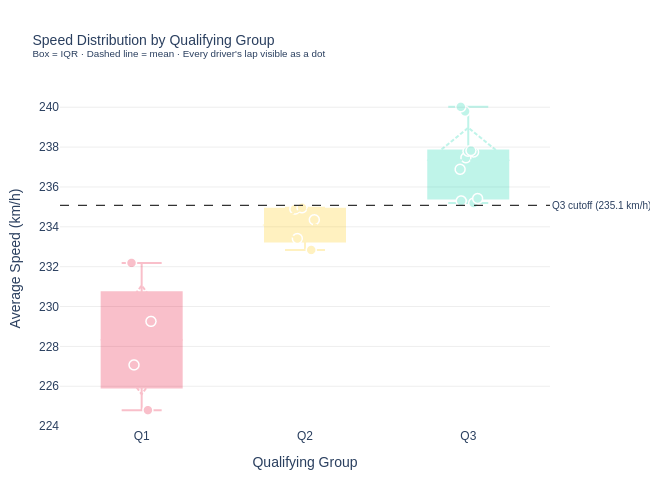

In [4]:
# ── Chart 2: Speed Distribution by Qualifying Group ───────────────────────
fig = go.Figure()

for grp in ["Q1", "Q2", "Q3"]:
    sub = tdf_c[tdf_c["group"] == grp]
    fig.add_trace(go.Box(
        x=[grp] * len(sub),
        y=sub["speed_mean"],
        name=grp,
        marker=dict(
            color=GROUP_COLORS[grp],
            size=10,
            line=dict(width=1.5, color="white")
        ),
        line=dict(color=GROUP_COLORS[grp], width=2),
        fillcolor=GROUP_COLORS[grp],
        opacity=0.25,
        boxpoints="all",
        jitter=0.3,
        pointpos=0,
        boxmean="sd",
        text=sub["driver"],
        hovertemplate="<b>%{text}</b><br>Speed: %{y:.1f} km/h<extra></extra>"
    ))

# Threshold line across groups
fig.add_hline(
    y=THRESHOLD,
    line_dash="dash", line_color="#333", line_width=1.2,
    annotation_text=f"Q3 cutoff ({THRESHOLD:.1f} km/h)",
    annotation_position="right",
    annotation_font_size=10,
)

fig.update_layout(
    title=dict(
        text="Speed Distribution by Qualifying Group<br>"
             "<sup>Box = IQR · Dashed line = mean · Every driver's lap visible as a dot</sup>",
        font=dict(size=14)
    ),
    xaxis=dict(title="Qualifying Group", categoryorder="array", categoryarray=["Q1", "Q2", "Q3"]),
    yaxis=dict(title="Average Speed (km/h)", showgrid=True, gridcolor="#eee"),
    template="plotly_white",
    showlegend=False,
    height=480, width=650,
    margin=dict(l=60, r=100, t=90, b=50)
)

fig.write_html("iframe_figures/figure_2.html", include_plotlyjs="cdn", full_html=True)
fig.show()

### Chart 3 — The Speed-Lap Time Relationship: Where the Threshold Lives

Average speed and lap duration are, by definition, inversely related. But this chart makes the Q3 boundary explicit:  
the vertical dashed line marks the speed threshold, and the gap between the 10th and 11th place drivers is annotated.

This is **semantic correspondence** in action (Lecture 14, Slide 28): the axis that matters (speed → Q3) is highlighted, not buried.

> *The context matters here too (Slide 30): "No chart speaks for itself." Without the annotation, a reader might miss that 0.2 km/h in average speed is the difference between Q3 and Q2 elimination.*

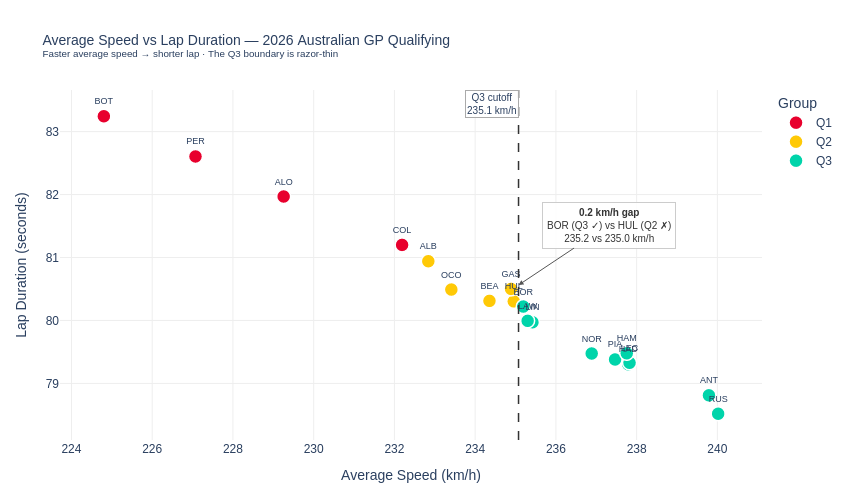

In [5]:
# ── Chart 3: Speed vs Lap Duration — The Threshold in Context ────────────
fig = go.Figure()

for grp in ["Q1", "Q2", "Q3"]:
    sub = tdf_c[tdf_c["group"] == grp]
    fig.add_trace(go.Scatter(
        x=sub["speed_mean"],
        y=sub["lap_duration"],
        mode="markers+text",
        marker=dict(size=14, color=GROUP_COLORS[grp],
                    line=dict(width=1.5, color="white")),
        text=sub["driver"],
        textposition="top center",
        textfont=dict(size=9),
        name=grp,
        hovertemplate=(
            "<b>%{text}</b><br>"
            "Speed: %{x:.1f} km/h<br>"
            "Lap: %{y:.2f}s<extra></extra>"
        )
    ))

# Threshold line
fig.add_vline(
    x=THRESHOLD,
    line_dash="dash", line_color="#333", line_width=1.5,
    annotation_text=f"Q3 cutoff<br>{THRESHOLD:.1f} km/h",
    annotation_position="top left",
    annotation_font_size=10,
    annotation_bgcolor="rgba(255,255,255,0.85)",
    annotation_bordercolor="#aaa",
)

# Annotate the boundary gap
bor = tdf_c[tdf_c["driver"] == "BOR"].iloc[0]
hul = tdf_c[tdf_c["driver"] == "HUL"].iloc[0]

fig.add_annotation(
    x=(bor["speed_mean"] + hul["speed_mean"]) / 2,
    y=(bor["lap_duration"] + hul["lap_duration"]) / 2 + 0.3,
    text=f"<b>0.2 km/h gap</b><br>BOR (Q3 ✓) vs HUL (Q2 ✗)<br>{bor['speed_mean']:.1f} vs {hul['speed_mean']:.1f} km/h",
    showarrow=True,
    arrowhead=2, arrowcolor="#555",
    ax=90, ay=-60,
    font=dict(size=10, color="#333"),
    bgcolor="rgba(255,255,255,0.9)",
    bordercolor="#ccc",
    borderwidth=1,
    borderpad=4
)

fig.update_layout(
    title=dict(
        text="Average Speed vs Lap Duration — 2026 Australian GP Qualifying<br>"
             "<sup>Faster average speed → shorter lap · The Q3 boundary is razor-thin</sup>",
        font=dict(size=14)
    ),
    xaxis=dict(title="Average Speed (km/h)", showgrid=True, gridcolor="#eee"),
    yaxis=dict(title="Lap Duration (seconds)", showgrid=True, gridcolor="#eee"),
    legend=dict(title="Group"),
    template="plotly_white",
    height=500, width=850,
    margin=dict(l=60, r=60, t=90, b=60)
)

fig.write_html("iframe_figures/figure_3.html", include_plotlyjs="cdn", full_html=True)
fig.show()

---
## Section 4 — What About the Other Driving Metrics?

We measured five telemetry features. The first two charts focused on speed.  
But what about throttle application and braking? Do they also differentiate Q3 from Q2/Q1?

**Small multiples** (Lecture 14, Slide 26) answer this in one view:  
the same chart structure, five times, for each feature — so the reader's eye can compare directly.

> *"Small multiples are a sequence of similar charts where the structure remains constant and only the values change. Repetition helps the reader focus on the data rather than on how the chart works."* — Lecture 14, Slide 26

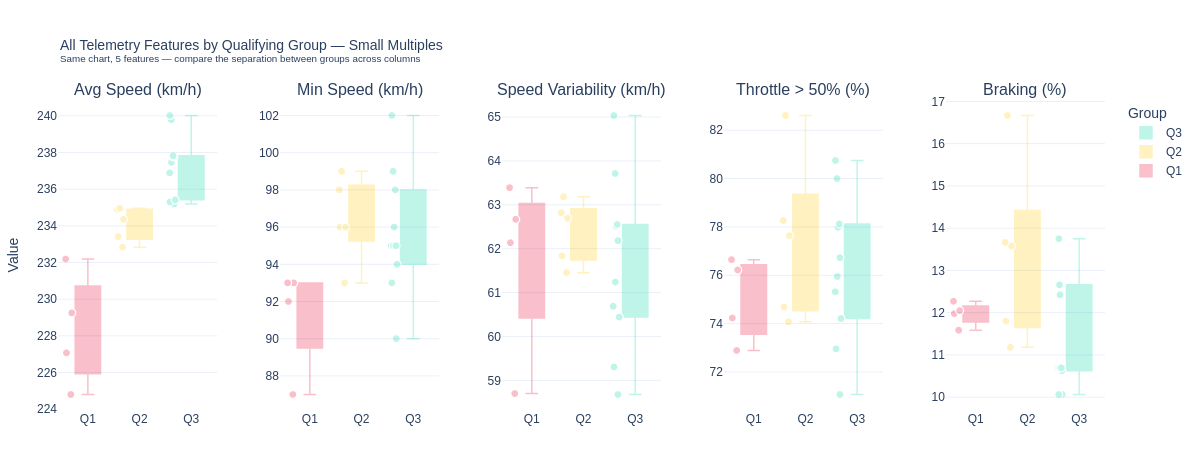

In [6]:
# ── Chart 4: Small Multiples — All 5 Features by Qualifying Group ─────────
feat_units = {
    "speed_mean":    "km/h",
    "speed_min":     "km/h",
    "speed_std":     "km/h",
    "throttle_pct": "%",
    "brake_pct":    "%",
}

fig = make_subplots(
    rows=1, cols=5,
    subplot_titles=[f"{FEATURE_LABELS[f]}\n({feat_units[f]})" for f in FEATURES],
    horizontal_spacing=0.06
)

for col_i, feat in enumerate(FEATURES, 1):
    for grp in ["Q1", "Q2", "Q3"]:
        sub = tdf_c[tdf_c["group"] == grp]
        fig.add_trace(
            go.Box(
                x=[grp] * len(sub),
                y=sub[feat],
                name=grp,
                marker=dict(
                    color=GROUP_COLORS[grp],
                    size=8,
                    line=dict(width=1.2, color="white")
                ),
                line=dict(color=GROUP_COLORS[grp], width=1.5),
                fillcolor=GROUP_COLORS[grp],
                opacity=0.25,
                boxpoints="all",
                jitter=0.3,
                boxmean=True,
                showlegend=(col_i == 1),
                hovertemplate=f"<b>%{{x}}</b><br>{FEATURE_LABELS[feat]}: %{{y:.1f}} {feat_units[feat]}<extra></extra>"
            ),
            row=1, col=col_i
        )

fig.update_layout(
    title=dict(
        text="All Telemetry Features by Qualifying Group — Small Multiples<br>"
             "<sup>Same chart, 5 features — compare the separation between groups across columns</sup>",
        font=dict(size=14)
    ),
    legend=dict(title="Group", traceorder="reversed"),
    template="plotly_white",
    height=460, width=1200,
    margin=dict(l=50, r=50, t=100, b=50)
)

# Consistent y-axis labels (only first column)
fig.update_yaxes(title_text="Value", col=1)

fig.write_html("iframe_figures/figure_4.html", include_plotlyjs="cdn", full_html=True)
fig.show()

**What the small multiples reveal:**

Look across the five panels:
- **Avg Speed** and **Min Speed**: clear vertical separation between Q3 (teal) and Q1 (red), with Q2 in between.
- **Speed Variability** (std dev): almost no separation — all groups overlap significantly.
- **Throttle > 50%** and **Braking**: minimal separation — the groups are nearly indistinguishable.

The conclusion is unambiguous: **cornering and straight-line speed discriminate; driving style metrics (throttle, brake) do not.**  
Albert Park is a power-limited circuit where top lap speed — not smoothness or aggression — determines who makes Q3.

> *This illustrates the principle of **cognitive efficiency** (Lecture 14, Slide 29): by using the same chart structure across all features, the reader instantly sees which features separate groups and which don't, without additional mental effort.*

---
## Section 5 — Machine Learning Confirms It

In Assignment 3, a Random Forest classifier achieved **100% LOOCV accuracy** predicting Q3 qualification from telemetry.  
The model was never shown a driver's qualifying result — it learned the boundary from raw numbers alone.

The chart below shows what the model found most useful — its internal ranking of which features reduced prediction error the most.

> *Visual integrity principle (Lecture 14, Slide 29): bars start at zero, values are labeled, and the chart does not distort the importance magnitude.*

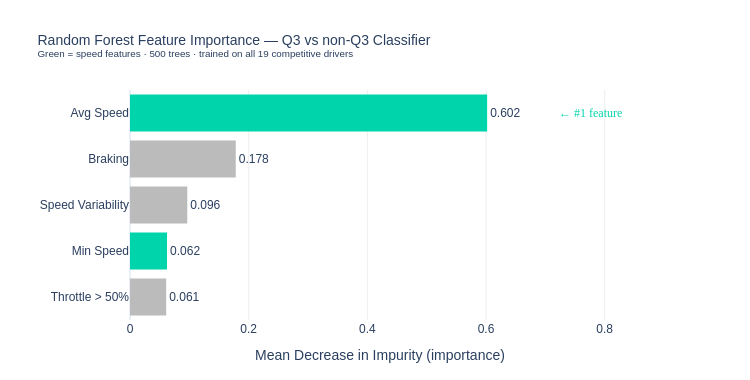

In [7]:
# ── Chart 5: Random Forest Feature Importance ─────────────────────────────
X_ml = tdf_c[FEATURES].values
y_ml = (tdf_c["group"] == "Q3").astype(int).values
scaler_ml = StandardScaler()
X_ml_scaled = scaler_ml.fit_transform(X_ml)

rf_full = RandomForestClassifier(n_estimators=500, random_state=42, max_features="sqrt")
rf_full.fit(X_ml_scaled, y_ml)

importances = pd.Series(rf_full.feature_importances_, index=FEATURES).sort_values(ascending=True)

bar_colors = ["#00D4AA" if f in ["speed_mean", "speed_min"] else "#BBBBBB"
              for f in importances.index]

fig = go.Figure()
fig.add_trace(go.Bar(
    x=importances.values,
    y=[FEATURE_LABELS[f] for f in importances.index],
    orientation="h",
    marker=dict(color=bar_colors, line=dict(width=0)),
    text=[f"{v:.3f}" for v in importances.values],
    textposition="outside",
    textfont=dict(size=12),
    hovertemplate="<b>%{y}</b><br>Importance: %{x:.3f}<extra></extra>"
))

# Highlight top feature
top_feat = FEATURE_LABELS[importances.index[-1]]
fig.add_annotation(
    x=importances.max() * 1.18,
    y=top_feat,
    text="  ← #1 feature",
    showarrow=False,
    font=dict(color="#00D4AA", size=12, family="Arial Black"),
    xanchor="left"
)

fig.update_layout(
    title=dict(
        text="Random Forest Feature Importance — Q3 vs non-Q3 Classifier<br>"
             "<sup>Green = speed features · 500 trees · trained on all 19 competitive drivers</sup>",
        font=dict(size=14)
    ),
    xaxis=dict(
        title="Mean Decrease in Impurity (importance)",
        range=[0, importances.max() * 1.4],
        showgrid=True, gridcolor="#eee"
    ),
    yaxis=dict(title=None, tickfont=dict(size=12)),
    template="plotly_white",
    showlegend=False,
    height=380, width=750,
    margin=dict(l=130, r=120, t=90, b=60)
)

fig.write_html("iframe_figures/figure_5.html", include_plotlyjs="cdn", full_html=True)
fig.show()

The Random Forest ranked **Avg Speed first and Min Speed second** — the same two variables that the Kruskal-Wallis test (Assignment 2) identified with effect sizes of ε² = 0.83 and ε² = 0.73 respectively. Throttle and braking features contribute little additional predictive power once speed is accounted for.

Two completely different methods (nonparametric statistics, ensemble ML) arrived at the same conclusion from the same data. That convergence is itself a finding worth communicating.

---
## Section 6 — The Outlier's Lesson

Any honest data story must address its anomalies.  
In this dataset, **Verstappen (VER)** is a textbook outlier: a 102-second lap compared to the 78–83 second range of all other drivers, with an average speed of 190 km/h versus 224–240 km/h for the competitive field.

This wasn't a slow driver — it was a **mechanical failure during an out-lap**: the car had a problem, Verstappen slowed down, and the lap time was never representative of his real pace.

> *Context matters (Lecture 14, Slide 30): "A chart without context invites misinterpretation. Always provide the data source, time period, and variable definitions. Context also means making limitations explicit."*

The chart below shows why VER was excluded from the main analysis — and why that exclusion was the right call, not data cherry-picking.

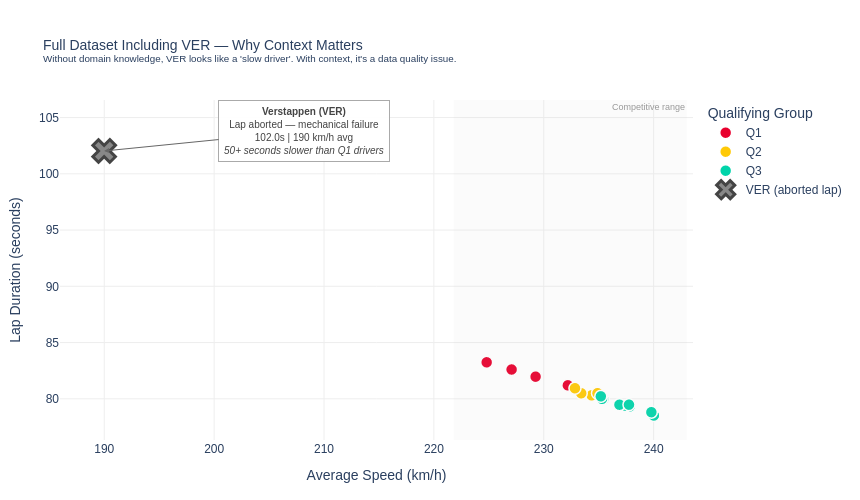

In [8]:
# ── Chart 6: The Outlier in Context ───────────────────────────────────────
fig = go.Figure()

# Competitive drivers
for grp in ["Q1", "Q2", "Q3"]:
    sub = tdf_c[tdf_c["group"] == grp]
    fig.add_trace(go.Scatter(
        x=sub["speed_mean"], y=sub["lap_duration"],
        mode="markers",
        marker=dict(size=12, color=GROUP_COLORS[grp],
                    line=dict(width=1.5, color="white")),
        name=grp,
        text=sub["driver"],
        hovertemplate="<b>%{text}</b><br>Speed: %{x:.1f} km/h<br>Lap: %{y:.1f}s<extra></extra>"
    ))

# VER
fig.add_trace(go.Scatter(
    x=[ver["speed_mean"]], y=[ver["lap_duration"]],
    mode="markers",
    marker=dict(size=20, color=VER_COLOR, symbol="x",
                line=dict(width=3, color="#444")),
    name="VER (aborted lap)",
    hovertemplate=(
        "<b>VER</b><br>"
        "Avg Speed: %{x:.1f} km/h<br>"
        "Lap: %{y:.1f}s<br>"
        "<i>Out-lap aborted — mechanical issue</i><extra></extra>"
    )
))

# VER annotation
fig.add_annotation(
    x=ver["speed_mean"], y=ver["lap_duration"],
    text=(
        "<b>Verstappen (VER)</b><br>"
        "Lap aborted — mechanical failure<br>"
        f"102.0s | {ver['speed_mean']:.0f} km/h avg<br>"
        "<i>50+ seconds slower than Q1 drivers</i>"
    ),
    showarrow=True,
    arrowhead=2, arrowcolor="#666",
    ax=200, ay=-20,
    font=dict(size=10, color="#444"),
    bgcolor="rgba(255,255,255,0.92)",
    bordercolor="#aaa",
    borderwidth=1,
    borderpad=5
)

# Shaded zone for competitive field
fig.add_vrect(
    x0=tdf_c["speed_mean"].min() - 3,
    x1=tdf_c["speed_mean"].max() + 3,
    fillcolor="rgba(200,200,200,0.07)",
    line_width=0,
    annotation_text="Competitive range",
    annotation_position="top right",
    annotation_font_size=9,
    annotation_font_color="#999"
)

fig.update_layout(
    title=dict(
        text="Full Dataset Including VER — Why Context Matters<br>"
             "<sup>Without domain knowledge, VER looks like a 'slow driver'. With context, it's a data quality issue.</sup>",
        font=dict(size=14)
    ),
    xaxis=dict(title="Average Speed (km/h)", showgrid=True, gridcolor="#eee"),
    yaxis=dict(title="Lap Duration (seconds)", showgrid=True, gridcolor="#eee"),
    legend=dict(title="Qualifying Group"),
    template="plotly_white",
    height=500, width=860,
    margin=dict(l=60, r=60, t=100, b=60)
)

fig.write_html("iframe_figures/figure_6.html", include_plotlyjs="cdn", full_html=True)
fig.show()

**The lesson:** data visualization makes outliers impossible to miss — but it takes domain knowledge to interpret them correctly. VER's lap time is a data quality issue, not a signal about his performance. Including it in an unsupervised clustering would have wasted an entire cluster on a single mechanical event.

This is one of the core principles of responsible data storytelling: **making limitations explicit** is not a weakness — it's a sign of analytical rigor.

---
## Section 7 — Three Methods, One Answer

This is the convergence moment in the data story — the point where all the evidence lines up.

Three independent methods, each with different assumptions and approaches, were applied to the same dataset:  
**Kruskal-Wallis statistical test**, **K-Means unsupervised clustering**, and **Random Forest supervised classification**.

The chart below compares how each method ranks the five features in terms of discriminative power.

> *Data storytelling component: Data (3 analyses) + Narrative (convergence) + Visualization (the chart below).*  
> *This is what Lecture 14, Slide 34 describes as the three essential components of a data-driven story.*

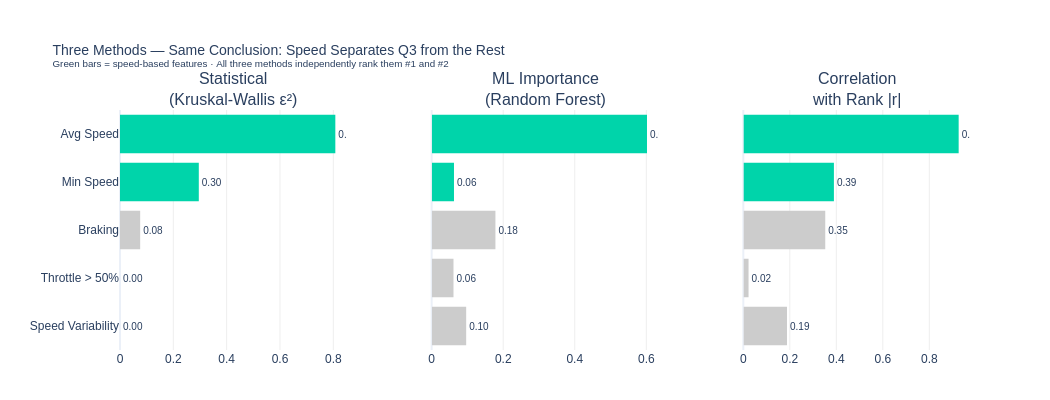

In [9]:
# ── Chart 7: Three Methods, One Answer — Convergence ─────────────────────

# Method 1: Kruskal-Wallis effect size (epsilon squared)
effect_sizes = {}
n = len(tdf_c)
k = 3  # number of groups
for feat in FEATURES:
    groups = [tdf_c[tdf_c["group"] == g][feat].dropna().values
              for g in ["Q1", "Q2", "Q3"]]
    stat, _ = kruskal(*groups)
    eps_sq = max(0, (stat - k + 1) / (n - k))
    effect_sizes[feat] = eps_sq

# Method 2: RF importances (already computed above)
rf_importances = dict(zip(FEATURES, rf_full.feature_importances_))

# Method 3: Pearson |correlation| with qualifying rank
correlations = {
    feat: abs(tdf_c[feat].corr(tdf_c["rank"]))
    for feat in FEATURES
}

# Build comparison DataFrame
methods = {
    "Statistical<br>(Kruskal-Wallis ε²)": effect_sizes,
    "ML Importance<br>(Random Forest)": rf_importances,
    "Correlation<br>with Rank |r|": correlations,
}

fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=list(methods.keys()),
    horizontal_spacing=0.10
)

feat_order = sorted(FEATURES, key=lambda f: effect_sizes[f])
feat_labels_ordered = [FEATURE_LABELS[f] for f in feat_order]
bar_colors = ["#00D4AA" if f in ["speed_mean", "speed_min"] else "#CCCCCC"
              for f in feat_order]

for col_i, (method_name, method_data) in enumerate(methods.items(), 1):
    vals = [method_data[f] for f in feat_order]
    fig.add_trace(
        go.Bar(
            x=vals,
            y=feat_labels_ordered,
            orientation="h",
            marker=dict(color=bar_colors, line=dict(width=0)),
            showlegend=False,
            text=[f"{v:.2f}" for v in vals],
            textposition="outside",
            textfont=dict(size=10),
            hovertemplate="%{y}: %{x:.3f}<extra></extra>"
        ),
        row=1, col=col_i
    )

# Shared design
for col_i in range(1, 4):
    fig.update_xaxes(showgrid=True, gridcolor="#eee", row=1, col=col_i)
    if col_i > 1:
        fig.update_yaxes(showticklabels=False, row=1, col=col_i)

fig.update_layout(
    title=dict(
        text="Three Methods — Same Conclusion: Speed Separates Q3 from the Rest<br>"
             "<sup>Green bars = speed-based features · All three methods independently rank them #1 and #2</sup>",
        font=dict(size=14)
    ),
    template="plotly_white",
    height=400, width=1050,
    margin=dict(l=120, r=80, t=110, b=50)
)

fig.write_html("iframe_figures/figure_7.html", include_plotlyjs="cdn", full_html=True)
fig.show()

**Reading the convergence chart:** In all three panels, **Avg Speed and Min Speed** (teal bars) are ranked #1 and #2. Throttle and braking (gray) rank last in every method. The specific values differ across methods because they measure different things — but the *ordering* is identical.

This is the core conclusion of all three assignments, stated once more with full evidence behind it:

> **In the 2026 Australian GP qualifying, what separates drivers who reach Q3 from those who don't is corner speed — the average and minimum speed maintained through Albert Park's technical sections.**

Three independent methods, one answer.

---
## Section 8 — Visualization Principles Applied

This section is an explicit reflection on the design choices made in this assignment, mapped to the principles from Lecture 14.

| Principle | Lecture Slide | How it was applied here |
|---|---|---|
| **Clarity first** | Slide 28 | Each chart has one primary message. No 3D effects, excessive colors, or decorative elements. |
| **Semantic correspondence** | Slide 28 | Speed is on the horizontal axis in ranking charts (left = slower, right = faster — intuitive for F1). Groups use the same three colors throughout. |
| **Visual integrity** | Slide 29 | All bar charts start at zero. Axes are not truncated. Effect sizes are labeled numerically. |
| **Cognitive efficiency** | Slide 29 | Small multiples (Chart 4) let the reader compare across features without re-learning the chart structure. The threshold line appears in every speed chart consistently. |
| **Context matters** | Slide 30 | Every chart has a subtitle with data source, method, and sample size. VER's exclusion is explicitly explained. |
| **Preattentive attributes** | Slide 24 | Color (qualifying group), position (rank/speed), and size (marker emphasis) all serve analytical roles — no decorative use of color. |
| **Small multiples** | Slide 26 | Chart 4 uses the same axes, scale logic, and structure across all 5 features, enabling direct visual comparison. |
| **Write the story first** | Slide 35 | The narrative arc was defined before building any chart: hook (Chart 1) → evidence (Charts 2-4) → ML confirmation (Chart 5) → outlier lesson (Chart 6) → convergence (Chart 7). |
| **Exploratory vs. Explanatory** | Slide 12 | All charts here are *explanatory*: they communicate known findings to an audience, not discover new ones. The exploratory work was done in Assignments 2 and 3. |

### What was deliberately avoided

- **Pie charts** for proportions — with 3 groups, a simple label is clearer
- **3D effects or gradients** — they add visual noise without information
- **Aggregate-only charts** (mean without spread) — with n=19, hiding individual points is misleading
- **Dual y-axes** — kept each chart to one message

---
## Conclusion

This assignment translated three assignments of analytical work into a visual narrative aimed at a hybrid audience: accessible enough for an F1 fan, rigorous enough for a technical reader.

### The data story in one paragraph

In Formula 1, qualifying for the front rows of the grid depends on a complex combination of car setup, driver skill, and race strategy. But at the 2026 Australian Grand Prix, one number explained everything: **average lap speed**. Drivers who maintained higher average speed — particularly through Albert Park's technical corner sequences — made it into Q3. Those who didn't, were eliminated. The gap between 10th and 11th place was just 0.2 km/h in average speed and 0.09 seconds in lap time. Three independent methods — a Kruskal-Wallis statistical test, a K-Means clustering algorithm, and a Random Forest classifier — all arrived at the same conclusion without being told the answer. When three different analytical approaches converge, that convergence is itself the story.

### Limitations

- **Sample size:** 19 drivers from a single qualifying session. The pattern may not hold at circuits with different layouts (low-speed vs. high-speed tracks).
- **Data granularity:** telemetry sampled at 2 Hz misses sub-second events (apex hits, track limit violations).
- **Single GP:** what separates Q3 at Albert Park (a street-circuit with tight corners) may be different at Monza (a power track with long straights).
- **VER exclusion:** removing an outlier is justified here, but any analysis excluding a data point must document why.

### Chart index

| # | Chart | Type | Key message |
|---|---|---|---|
| 1 | Driver Speed Ranking | Lollipop | Speed separates Q3/Q2/Q1 visually |
| 2 | Speed Distribution by Group | Box + strip | Distributions are distinct, not overlapping |
| 3 | Speed vs Lap Duration | Scatter | The Q3 boundary is 0.2 km/h / 0.09s |
| 4 | All Features — Small Multiples | Box × 5 | Only speed features discriminate |
| 5 | RF Feature Importance | H-bar | ML ranked speed #1 and #2 |
| 6 | Outlier in Context | Scatter | VER's lap is a data quality issue, not a performance signal |
| 7 | Three Methods Convergence | H-bar × 3 | All methods agree on the same answer |